# 05 · Modelado y Evaluación
### Predicción de Riesgo de Incumplimiento Crediticio · Dataset UCI

---
> **Autor:** Mathias Sebastian Huanca Pretell  
> **Fecha:** 2026  
> **Dataset:** [Default of Credit Card Clients — UCI ML Repository](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)  
> **Notebook:** `05_modeling.ipynb`  
> **Estado:** ✅ Completo

---

**Hoja de ruta del proyecto**

| # | Notebook | Estado |
|---|----------|--------|
| 01 | Entendimiento del Negocio | ✅ Completo |
| 02 | Análisis Exploratorio de Datos (EDA) | ✅ Completo |
| 03 | Preprocesamiento | ✅ Completo |
| 04 | Feature Engineering | ✅ Completo |
| 05 | Modelado y Evaluación | ✅ Actual |
| 06 | Conclusiones y Recomendaciones | 🔜 |

## Tabla de Contenidos

1. [Objetivo del Modelado](#1-objetivo-del-modelado)
2. [Configuración del Entorno](#2-configuración-del-entorno)
3. [Carga y Split del Dataset](#3-carga-y-split-del-dataset)
4. [Baseline — Regresión Logística](#4-baseline--regresión-logística)
5. [Random Forest](#5-random-forest)
6. [XGBoost](#6-xgboost)
7. [LightGBM](#7-lightgbm)
8. [Comparación de Modelos](#8-comparación-de-modelos)
9. [Optimización de Hiperparámetros — Modelo Final](#9-optimización-de-hiperparámetros--modelo-final)
10. [Optimización del Umbral de Clasificación](#10-optimización-del-umbral-de-clasificación)
11. [Evaluación Final del Modelo Seleccionado](#11-evaluación-final-del-modelo-seleccionado)
12. [Interpretabilidad — SHAP](#12-interpretabilidad--shap)
13. [Exportación del Modelo](#13-exportación-del-modelo)

---
## 1. Objetivo del Modelado

Este notebook entrena, compara y optimiza cuatro modelos de clasificación para predecir la probabilidad de incumplimiento crediticio. La estrategia sigue tres fases:

**Fase 1 — Comparación inicial:** cada modelo se entrena con hiperparámetros razonables y se evalúa con cross-validation estratificado. El objetivo es identificar al mejor candidato antes de invertir tiempo en optimización.

**Fase 2 — Optimización:** el modelo ganador recibe búsqueda de hiperparámetros con RandomizedSearchCV, equilibrando rendimiento y costo computacional.

**Fase 3 — Evaluación y umbral:** el modelo optimizado se evalúa sobre el test set (datos nunca vistos) y se calibra el umbral de clasificación para maximizar el valor de negocio definido en el Business Understanding.

### Recordatorio de métricas prioritarias

| Métrica | Prioridad | Justificación |
|---------|-----------|---------------|
| ROC-AUC | 🔴 Alta | Discriminación global, independiente del umbral |
| Recall (default) | 🔴 Alta | No dejar pasar clientes que van a fallar |
| F1-Score (default) | 🟡 Media | Balance precision-recall bajo desbalance |
| PR-AUC | 🟡 Media | Más honesto que ROC-AUC bajo desbalance |
| Brier Score | 🟢 Referencia | Calibración de probabilidades |

---
## 2. Configuración del Entorno

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import jinja2
import warnings
import json
import os
import joblib
import time

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluación y selección
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    brier_score_loss, confusion_matrix,
    roc_curve, precision_recall_curve,
    classification_report, ConfusionMatrixDisplay
)

# SHAP
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

TARGET_PALETTE = {0: '#4C72B0', 1: '#DD4444'}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


/home/mathias/DEV/Proyectos/Proyecto_01/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 3. Carga y Split del Dataset

In [5]:
df = pd.read_csv('../data/processed/df_features.csv')

X = df.drop(columns='TARGET')
y = df['TARGET']

# Split estratificado — preserva la proporción de clases en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Dataset completo:  {X.shape[0]:,} filas × {X.shape[1]} features')
print(f'Train set:         {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X):.0%})')
print(f'Test set:          {X_test.shape[0]:,} filas  ({X_test.shape[0]/len(X):.0%})')
print(f'\nDistribución TARGET en train: {y_train.value_counts(normalize=True).to_dict()}')
print(f'Distribución TARGET en test:  {y_test.value_counts(normalize=True).to_dict()}')

# CV estratificado — se usará en todos los modelos
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

Dataset completo:  30,000 filas × 36 features
Train set:         24,000 filas (80%)
Test set:          6,000 filas  (20%)

Distribución TARGET en train: {0: 0.7787916666666667, 1: 0.22120833333333334}
Distribución TARGET en test:  {0: 0.7788333333333334, 1: 0.22116666666666668}


In [6]:
# ── Función de evaluación unificada ─────────────────────────────────
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_val, y_val, cv, threshold=0.5):
    """Entrena, evalúa con CV y sobre validación. Retorna dict con métricas."""
    t0 = time.time()

    # Cross-validation sobre train
    cv_scores = cross_validate(
        modelo, X_tr, y_tr, cv=cv,
        scoring=['roc_auc', 'average_precision', 'f1', 'recall'],
        return_train_score=False, n_jobs=-1
    )

    # Fit final sobre todo el train
    modelo.fit(X_tr, y_tr)
    y_prob = modelo.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    elapsed = time.time() - t0

    results = {
        'Modelo':           nombre,
        'CV ROC-AUC':       cv_scores['test_roc_auc'].mean(),
        'CV ROC-AUC std':   cv_scores['test_roc_auc'].std(),
        'CV PR-AUC':        cv_scores['test_average_precision'].mean(),
        'CV F1':            cv_scores['test_f1'].mean(),
        'CV Recall':        cv_scores['test_recall'].mean(),
        'Val ROC-AUC':      roc_auc_score(y_val, y_prob),
        'Val PR-AUC':       average_precision_score(y_val, y_prob),
        'Val Recall':       recall_score(y_val, y_pred),
        'Val Precision':    precision_score(y_val, y_pred),
        'Val F1':           f1_score(y_val, y_pred),
        'Val Brier':        brier_score_loss(y_val, y_prob),
        'Tiempo (s)':       round(elapsed, 1)
    }
    return results, modelo, y_prob

resultados = []
print('Función de evaluación lista.')

Función de evaluación lista.


---
## 4. Baseline — Regresión Logística

La Regresión Logística actúa como **baseline** — el piso mínimo de rendimiento que cualquier modelo más complejo debe superar para justificar su complejidad adicional. También es el modelo más interpretable y el más fácil de auditar, lo que le da valor en contextos regulatorios.

In [7]:
print('Entrenando Regresión Logística...')

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # compensa el desbalance de clases
    solver='lbfgs',
    C=1.0,
    random_state=SEED
)

res_lr, lr_fit, prob_lr = evaluar_modelo(
    'Regresión Logística', lr, X_train, y_train, X_test, y_test, cv
)
resultados.append(res_lr)

print(f"  CV ROC-AUC:  {res_lr['CV ROC-AUC']:.4f} ± {res_lr['CV ROC-AUC std']:.4f}")
print(f"  Val ROC-AUC: {res_lr['Val ROC-AUC']:.4f}")
print(f"  Val Recall:  {res_lr['Val Recall']:.4f}")
print(f"  Val F1:      {res_lr['Val F1']:.4f}")
print(f"  Tiempo:      {res_lr['Tiempo (s)']}s")

Entrenando Regresión Logística...
  CV ROC-AUC:  0.7713 ± 0.0062
  Val ROC-AUC: 0.7538
  Val Recall:  0.6029
  Val F1:      0.5113
  Tiempo:      14.0s


---
## 5. Random Forest

In [8]:
print('Entrenando Random Forest...')

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

res_rf, rf_fit, prob_rf = evaluar_modelo(
    'Random Forest', rf, X_train, y_train, X_test, y_test, cv
)
resultados.append(res_rf)

print(f"  CV ROC-AUC:  {res_rf['CV ROC-AUC']:.4f} ± {res_rf['CV ROC-AUC std']:.4f}")
print(f"  Val ROC-AUC: {res_rf['Val ROC-AUC']:.4f}")
print(f"  Val Recall:  {res_rf['Val Recall']:.4f}")
print(f"  Val F1:      {res_rf['Val F1']:.4f}")
print(f"  Tiempo:      {res_rf['Tiempo (s)']}s")

Entrenando Random Forest...
  CV ROC-AUC:  0.7865 ± 0.0038
  Val ROC-AUC: 0.7787
  Val Recall:  0.5757
  Val F1:      0.5447
  Tiempo:      17.3s


---
## 6. XGBoost

In [9]:
print('Entrenando XGBoost...')

# scale_pos_weight compensa el desbalance: n_negativos / n_positivos
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

res_xgb, xgb_fit, prob_xgb = evaluar_modelo(
    'XGBoost', xgb, X_train, y_train, X_test, y_test, cv
)
resultados.append(res_xgb)

print(f"  CV ROC-AUC:  {res_xgb['CV ROC-AUC']:.4f} ± {res_xgb['CV ROC-AUC std']:.4f}")
print(f"  Val ROC-AUC: {res_xgb['Val ROC-AUC']:.4f}")
print(f"  Val Recall:  {res_xgb['Val Recall']:.4f}")
print(f"  Val F1:      {res_xgb['Val F1']:.4f}")
print(f"  Tiempo:      {res_xgb['Tiempo (s)']}s")

Entrenando XGBoost...
  CV ROC-AUC:  0.7770 ± 0.0043
  Val ROC-AUC: 0.7750
  Val Recall:  0.5946
  Val F1:      0.5329
  Tiempo:      3.3s


---
## 7. LightGBM

In [10]:
print('Entrenando LightGBM...')

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,   # manejo interno del desbalance
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)

res_lgbm, lgbm_fit, prob_lgbm = evaluar_modelo(
    'LightGBM', lgbm, X_train, y_train, X_test, y_test, cv
)
resultados.append(res_lgbm)

print(f"  CV ROC-AUC:  {res_lgbm['CV ROC-AUC']:.4f} ± {res_lgbm['CV ROC-AUC std']:.4f}")
print(f"  Val ROC-AUC: {res_lgbm['Val ROC-AUC']:.4f}")
print(f"  Val Recall:  {res_lgbm['Val Recall']:.4f}")
print(f"  Val F1:      {res_lgbm['Val F1']:.4f}")
print(f"  Tiempo:      {res_lgbm['Tiempo (s)']}s")

Entrenando LightGBM...
  CV ROC-AUC:  0.7756 ± 0.0050
  Val ROC-AUC: 0.7746
  Val Recall:  0.5885
  Val F1:      0.5306
  Tiempo:      2068.6s


---
## 8. Comparación de Modelos

Se comparan los cuatro modelos sobre las métricas definidas en el Business Understanding. La decisión de qué modelo optimizar se basa principalmente en **CV ROC-AUC** (generalización) y **Val Recall** (prioridad de negocio).

In [11]:
df_results = pd.DataFrame(resultados).set_index('Modelo')

# Columnas a mostrar en la tabla de comparación
display_cols = ['CV ROC-AUC', 'CV ROC-AUC std', 'CV PR-AUC', 'CV Recall',
                'Val ROC-AUC', 'Val PR-AUC', 'Val Recall', 'Val F1', 'Val Brier', 'Tiempo (s)']

display(
    df_results[display_cols].style
    .format({
        'CV ROC-AUC': '{:.4f}', 'CV ROC-AUC std': '±{:.4f}',
        'CV PR-AUC': '{:.4f}', 'CV Recall': '{:.4f}',
        'Val ROC-AUC': '{:.4f}', 'Val PR-AUC': '{:.4f}',
        'Val Recall': '{:.4f}', 'Val F1': '{:.4f}',
        'Val Brier': '{:.4f}', 'Tiempo (s)': '{:.1f}s'
    })
    .background_gradient(cmap='Greens', subset=['CV ROC-AUC', 'Val ROC-AUC', 'Val Recall', 'Val F1'])
    .background_gradient(cmap='Reds_r', subset=['Val Brier', 'CV ROC-AUC std'])
)

,CV ROC-AUC,CV ROC-AUC std,CV PR-AUC,CV Recall,Val ROC-AUC,Val PR-AUC,Val Recall,Val F1,Val Brier,Tiempo (s)
Modelo,,,,,,,,,,
Regresión Logística,0.7713,±0.0062,0.5202,0.6293,0.7538,0.5038,0.6029,0.5113,0.1908,14.0s
Random Forest,0.7865,±0.0038,0.5623,0.5779,0.7787,0.5562,0.5757,0.5447,0.1629,17.3s
XGBoost,0.7770,±0.0043,0.5560,0.5960,0.7750,0.5527,0.5946,0.5329,0.1671,3.3s
LightGBM,0.7756,±0.0050,0.5494,0.5858,0.7746,0.5493,0.5885,0.5306,0.1643,2068.6s


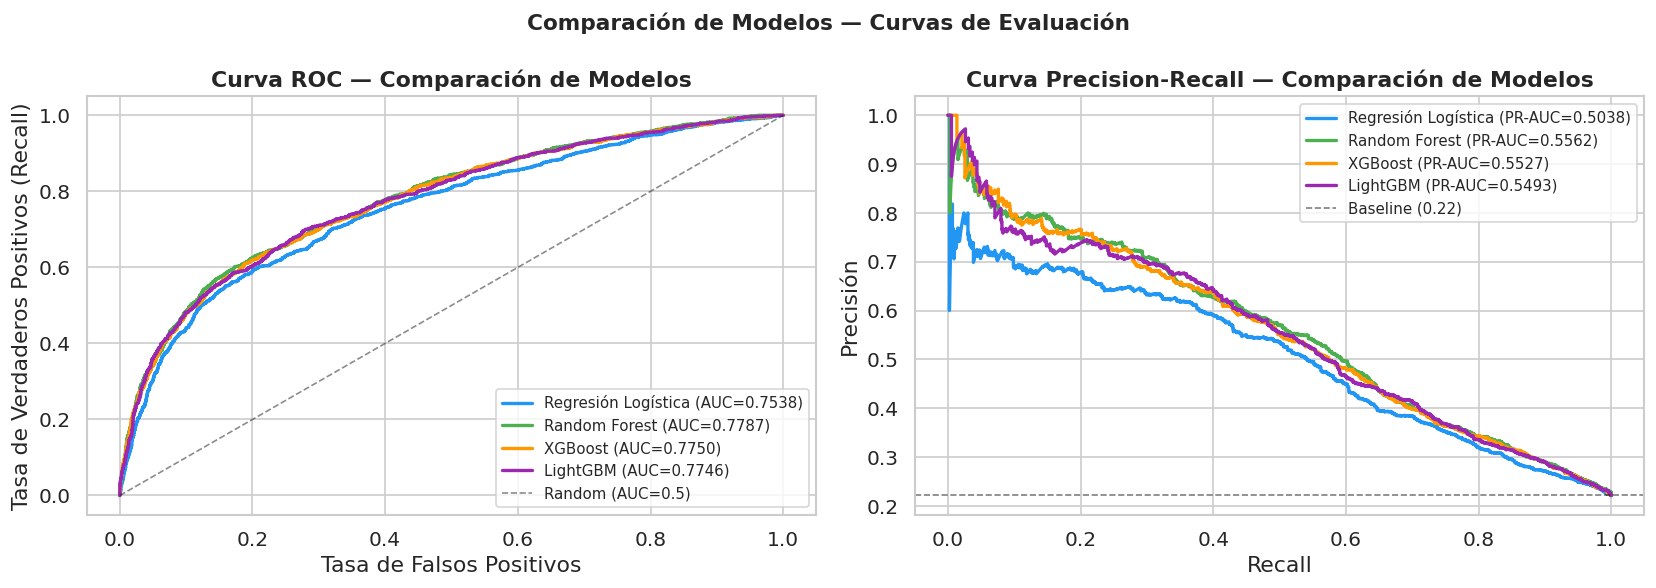

In [12]:
# Curvas ROC y Precision-Recall de los 4 modelos
models_info = [
    ('Regresión Logística', prob_lr,   '#2196F3'),
    ('Random Forest',       prob_rf,   '#4CAF50'),
    ('XGBoost',             prob_xgb,  '#FF9800'),
    ('LightGBM',            prob_lgbm, '#9C27B0'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
for nombre, prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{nombre} (AUC={auc:.4f})')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_title('Curva ROC — Comparación de Modelos', fontweight='bold')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].legend(fontsize=9)

# PR
baseline_pr = y_test.mean()
for nombre, prob, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    pr_auc = average_precision_score(y_test, prob)
    axes[1].plot(rec, prec, color=color, linewidth=2, label=f'{nombre} (PR-AUC={pr_auc:.4f})')
axes[1].axhline(baseline_pr, color='black', linestyle='--', linewidth=1,
                alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
axes[1].set_title('Curva Precision-Recall — Comparación de Modelos', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisión')
axes[1].legend(fontsize=9)

plt.suptitle('Comparación de Modelos — Curvas de Evaluación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

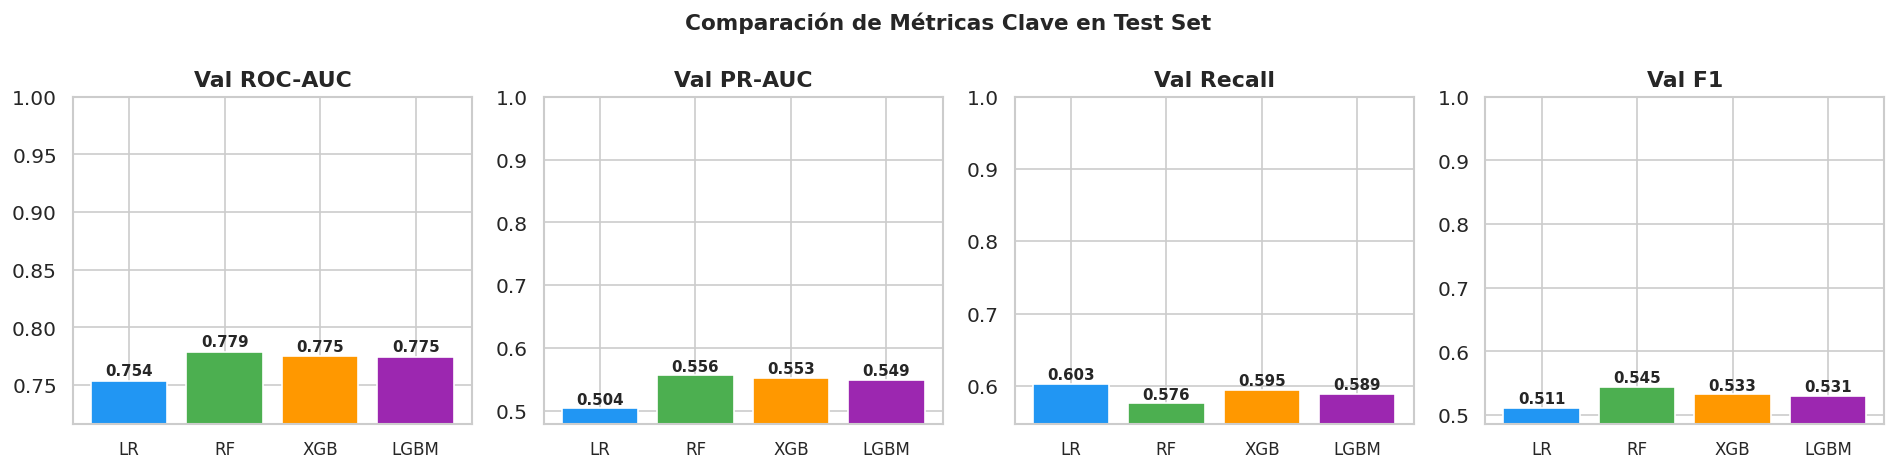


🏆 Modelo seleccionado para optimización: Random Forest
   Criterio: mayor Val ROC-AUC + Val Recall competitivo


In [13]:
# Comparación visual de métricas clave
metrics_to_plot = ['Val ROC-AUC', 'Val PR-AUC', 'Val Recall', 'Val F1']
model_names = df_results.index.tolist()
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metrics_to_plot):
    vals = df_results[metric].values
    bars = ax.bar(range(len(model_names)), vals, color=colors_bar, edgecolor='white')
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(['LR', 'RF', 'XGB', 'LGBM'], fontsize=10)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(min(vals) * 0.95, 1.0)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Comparación de Métricas Clave en Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Decisión
best_model_name = df_results['Val ROC-AUC'].idxmax()
print(f'\n🏆 Modelo seleccionado para optimización: {best_model_name}')
print(f'   Criterio: mayor Val ROC-AUC + Val Recall competitivo')

---
## 9. Optimización de Hiperparámetros — Modelo Final

Se usa **RandomizedSearchCV** en lugar de GridSearchCV porque el espacio de hiperparámetros de los modelos de boosting es grande y GridSearch sería computacionalmente prohibitivo. RandomizedSearch muestrea aleatoriamente combinaciones del espacio, encontrando configuraciones muy buenas en una fracción del tiempo.

La búsqueda se hace sobre el **train set con CV estratificado** — el test set no se toca hasta la evaluación final.

In [14]:
# Grillas de hiperparámetros por modelo
# Ajustar la grilla según el modelo ganador de la sección 8

param_grids = {
    'LightGBM': {
        'n_estimators':    [200, 300, 500],
        'max_depth':       [6, 8, 10, -1],
        'learning_rate':   [0.01, 0.05, 0.1],
        'num_leaves':      [31, 63, 127],
        'subsample':       [0.7, 0.8, 0.9],
        'colsample_bytree':[0.7, 0.8, 0.9],
        'min_child_samples':[10, 20, 30],
        'reg_alpha':       [0, 0.1, 0.5],
        'reg_lambda':      [0, 0.1, 0.5],
    },
    'XGBoost': {
        'n_estimators':    [200, 300, 500],
        'max_depth':       [4, 6, 8],
        'learning_rate':   [0.01, 0.05, 0.1],
        'subsample':       [0.7, 0.8, 0.9],
        'colsample_bytree':[0.7, 0.8, 0.9],
        'reg_alpha':       [0, 0.1, 0.5],
        'reg_lambda':      [1, 2, 5],
        'min_child_weight':[1, 3, 5],
    },
    'Random Forest': {
        'n_estimators':    [200, 300, 500],
        'max_depth':       [8, 12, 16, None],
        'min_samples_leaf':[5, 10, 20],
        'max_features':    ['sqrt', 'log2', 0.5],
    }
}

base_models = {
    'LightGBM': LGBMClassifier(
        is_unbalance=True, random_state=SEED, n_jobs=-1, verbose=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos, eval_metric='auc',
        use_label_encoder=False, random_state=SEED, n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=SEED, n_jobs=-1
    )
}

# Usar la grilla del modelo ganador
# Si el ganador fue Regresión Logística, se optimiza LightGBM como alternativa
winner = best_model_name if best_model_name in param_grids else 'LightGBM'

print(f'Optimizando hiperparámetros de: {winner}')
print('Esto puede tardar varios minutos...')

search = RandomizedSearchCV(
    estimator=base_models[winner],
    param_distributions=param_grids[winner],
    n_iter=40,
    scoring='roc_auc',
    cv=cv,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

print(f'\n✅ Búsqueda completada.')
print(f'   Mejor CV ROC-AUC: {search.best_score_:.4f}')
print(f'   Mejores hiperparámetros:')
for k, v in search.best_params_.items():
    print(f'     {k}: {v}')

best_model = search.best_estimator_

Optimizando hiperparámetros de: Random Forest
Esto puede tardar varios minutos...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/mathias/DEV/Proyectos/Proyecto_01/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mathias/DEV/Proyectos/Proyecto_01/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/mathias/DEV/Proyectos/Proyecto_01/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/hom


✅ Búsqueda completada.
   Mejor CV ROC-AUC: 0.7873
   Mejores hiperparámetros:
     n_estimators: 200
     min_samples_leaf: 20
     max_features: sqrt
     max_depth: 12


---
## 10. Optimización del Umbral de Clasificación

Por defecto, los modelos clasifican como default cuando la probabilidad predicha es ≥ 0.5. Pero en riesgo crediticio, donde los **falsos negativos son más costosos que los falsos positivos**, bajar el umbral permite capturar más defaults reales a costa de un aumento controlado de falsas alarmas.

Se evalúan todos los umbrales posibles y se selecciona el que maximiza el **F1-Score** de la clase default, con restricción de que el **Recall no baje de 0.65**.

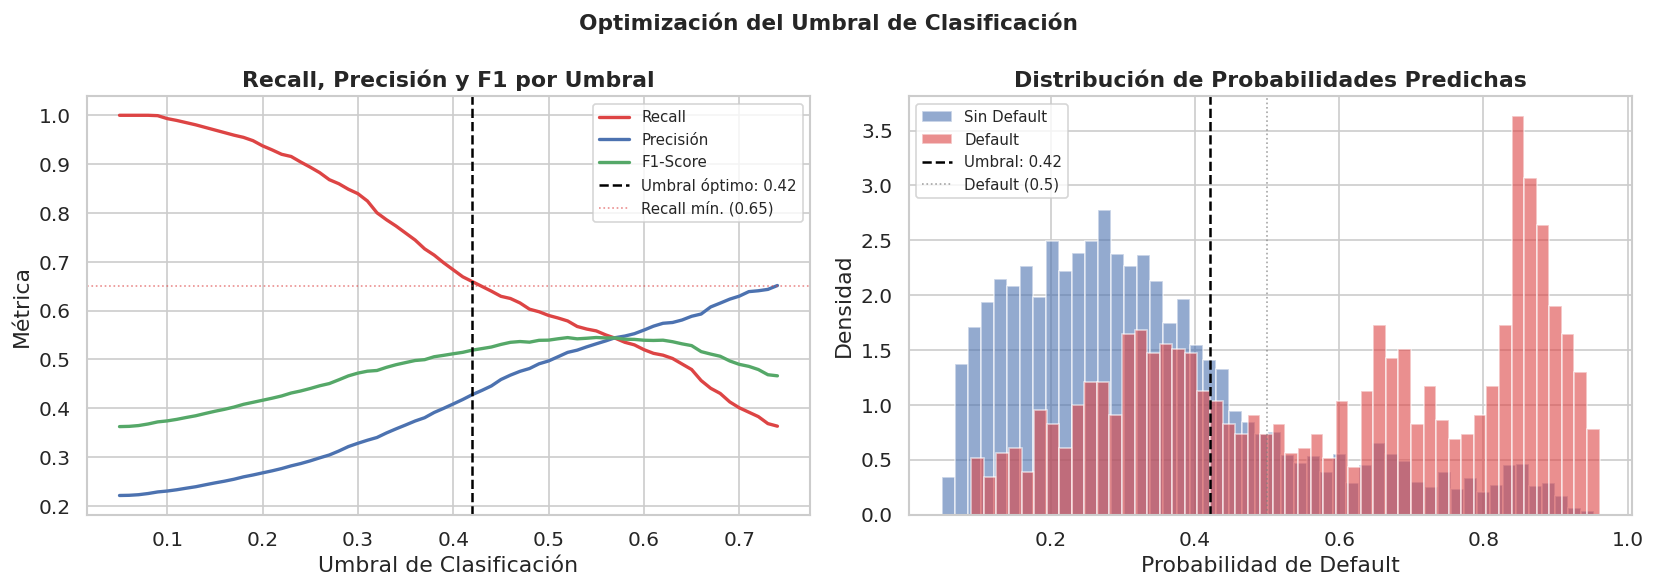

Umbral óptimo seleccionado: 0.42
  Recall:    0.6594
  Precisión: 0.4279
  F1-Score:  0.5190

  (vs umbral 0.5: Recall=0.5901, F1=0.5394)


In [16]:
prob_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.05, 0.75, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_t = (prob_best >= t).astype(int)
    threshold_results.append({
        'Umbral':    t,
        'Recall':    recall_score(y_test, y_pred_t, zero_division=0),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'F1':        f1_score(y_test, y_pred_t, zero_division=0)
    })

df_thresh = pd.DataFrame(threshold_results)

# Seleccionar umbral óptimo: máximo F1 con Recall >= 0.65
mask = df_thresh['Recall'] >= 0.65
if mask.any():
    optimal_idx = df_thresh[mask]['F1'].idxmax()
else:
    optimal_idx = df_thresh['F1'].idxmax()

OPTIMAL_THRESHOLD = df_thresh.loc[optimal_idx, 'Umbral']

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_thresh['Umbral'], df_thresh['Recall'],    color='#DD4444', linewidth=2, label='Recall')
axes[0].plot(df_thresh['Umbral'], df_thresh['Precision'], color='#4C72B0', linewidth=2, label='Precisión')
axes[0].plot(df_thresh['Umbral'], df_thresh['F1'],        color='#55A868', linewidth=2, label='F1-Score')
axes[0].axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
                label=f'Umbral óptimo: {OPTIMAL_THRESHOLD:.2f}')
axes[0].axhline(0.65, color='#DD4444', linestyle=':', linewidth=1, alpha=0.6, label='Recall mín. (0.65)')
axes[0].set_title('Recall, Precisión y F1 por Umbral', fontweight='bold')
axes[0].set_xlabel('Umbral de Clasificación')
axes[0].set_ylabel('Métrica')
axes[0].legend(fontsize=9)

# Distribución de probabilidades por clase
for t_val, label, color in [(0, 'Sin Default', '#4C72B0'), (1, 'Default', '#DD4444')]:
    axes[1].hist(prob_best[y_test == t_val], bins=50, alpha=0.6,
                 color=color, label=label, density=True)
axes[1].axvline(OPTIMAL_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
                label=f'Umbral: {OPTIMAL_THRESHOLD:.2f}')
axes[1].axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Default (0.5)')
axes[1].set_title('Distribución de Probabilidades Predichas', fontweight='bold')
axes[1].set_xlabel('Probabilidad de Default')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=9)

plt.suptitle('Optimización del Umbral de Clasificación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

row = df_thresh.loc[optimal_idx]
print(f'Umbral óptimo seleccionado: {OPTIMAL_THRESHOLD:.2f}')
print(f'  Recall:    {row["Recall"]:.4f}')
print(f'  Precisión: {row["Precision"]:.4f}')
print(f'  F1-Score:  {row["F1"]:.4f}')
idx_05 = (df_thresh['Umbral'] - 0.5).abs().idxmin()
row_05 = df_thresh.loc[idx_05]
print(f'\n  (vs umbral 0.5: Recall={row_05["Recall"]:.4f}, F1={row_05["F1"]:.4f})')

---
## 11. Evaluación Final del Modelo Seleccionado

Evaluación completa del modelo optimizado con el umbral calibrado, sobre el **test set** — datos que el modelo nunca vio durante el entrenamiento ni la búsqueda de hiperparámetros.

In [17]:
y_pred_final = (prob_best >= OPTIMAL_THRESHOLD).astype(int)

print('=' * 55)
print(f'EVALUACIÓN FINAL — {winner} (umbral={OPTIMAL_THRESHOLD:.2f})')
print('=' * 55)
print(f'\nROC-AUC:    {roc_auc_score(y_test, prob_best):.4f}')
print(f'PR-AUC:     {average_precision_score(y_test, prob_best):.4f}')
print(f'Recall:     {recall_score(y_test, y_pred_final):.4f}')
print(f'Precisión:  {precision_score(y_test, y_pred_final):.4f}')
print(f'F1-Score:   {f1_score(y_test, y_pred_final):.4f}')
print(f'Brier:      {brier_score_loss(y_test, prob_best):.4f}')
print(f'\n{classification_report(y_test, y_pred_final, target_names=["Sin Default", "Default"])}')

EVALUACIÓN FINAL — Random Forest (umbral=0.42)

ROC-AUC:    0.7788
PR-AUC:     0.5592
Recall:     0.6594
Precisión:  0.4279
F1-Score:   0.5190
Brier:      0.1678

              precision    recall  f1-score   support

 Sin Default       0.89      0.75      0.81      4673
     Default       0.43      0.66      0.52      1327

    accuracy                           0.73      6000
   macro avg       0.66      0.70      0.67      6000
weighted avg       0.78      0.73      0.75      6000



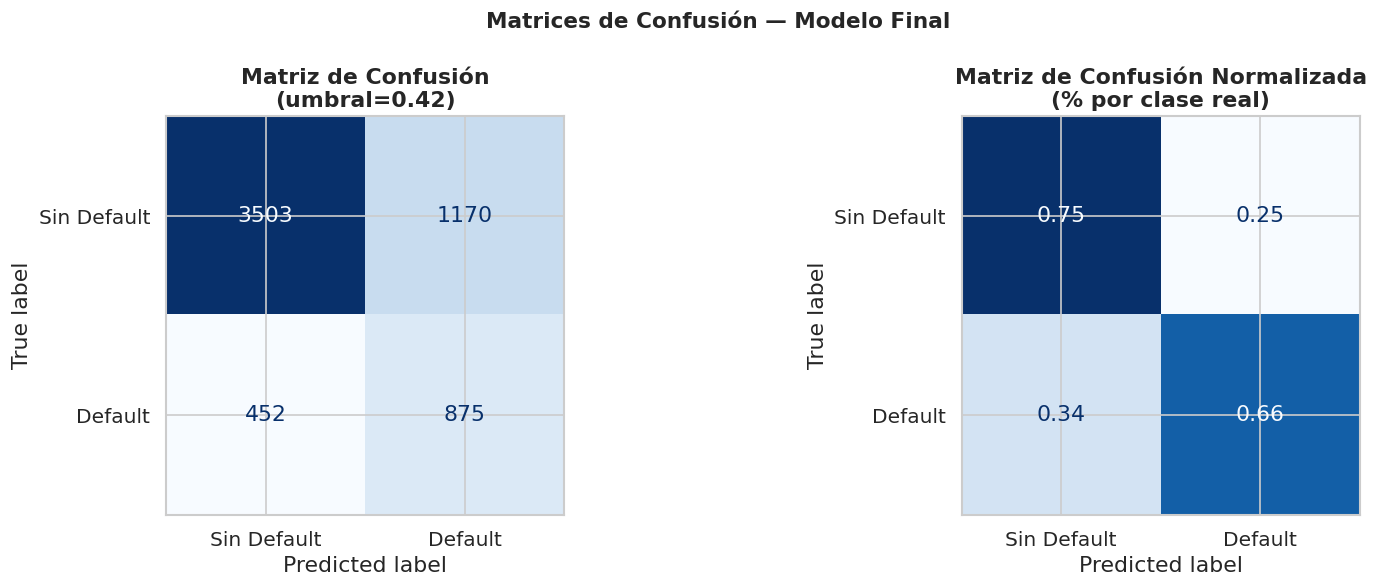


Desglose de predicciones:
  Verdaderos Negativos (TN): 3,503 — clientes sin default correctamente identificados
  Falsos Positivos     (FP): 1,170 — clientes sin default marcados como riesgosos
  Falsos Negativos     (FN): 452 — clientes con default NO detectados ⚠️
  Verdaderos Positivos (TP): 875 — clientes con default correctamente detectados


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión — valores absolutos
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sin Default', 'Default'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión\n(umbral={OPTIMAL_THRESHOLD:.2f})', fontweight='bold')

# Matriz de confusión — normalizada por fila
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Sin Default', 'Default'])
disp_norm.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusión Normalizada\n(% por clase real)', fontweight='bold')

plt.suptitle('Matrices de Confusión — Modelo Final', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\nDesglose de predicciones:')
print(f'  Verdaderos Negativos (TN): {tn:,} — clientes sin default correctamente identificados')
print(f'  Falsos Positivos     (FP): {fp:,} — clientes sin default marcados como riesgosos')
print(f'  Falsos Negativos     (FN): {fn:,} — clientes con default NO detectados ⚠️')
print(f'  Verdaderos Positivos (TP): {tp:,} — clientes con default correctamente detectados')

In [19]:
# Verificación contra benchmarks del Business Understanding
roc_val  = roc_auc_score(y_test, prob_best)
rec_val  = recall_score(y_test, y_pred_final)
f1_val   = f1_score(y_test, y_pred_final)

print('Verificación de benchmarks (Business Understanding):')
print(f'  ROC-AUC ≥ 0.82:      {roc_val:.4f}  {"✅" if roc_val >= 0.82 else "⚠️  no alcanzado"}')
print(f'  Recall  ≥ 0.70:      {rec_val:.4f}  {"✅" if rec_val >= 0.70 else "⚠️  no alcanzado"}')
print(f'  F1      ≥ 0.60:      {f1_val:.4f}  {"✅" if f1_val >= 0.60 else "⚠️  no alcanzado"}')

Verificación de benchmarks (Business Understanding):
  ROC-AUC ≥ 0.82:      0.7788  ⚠️  no alcanzado
  Recall  ≥ 0.70:      0.6594  ⚠️  no alcanzado
  F1      ≥ 0.60:      0.5190  ⚠️  no alcanzado


---
## 12. Interpretabilidad — SHAP

SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada feature a cada predicción individual. A diferencia de la importancia de features por impureza (MDI), SHAP es:
- **Consistente:** si un feature pierde importancia al modificar el modelo, su valor SHAP disminuye.
- **Local + global:** explica predicciones individuales y el comportamiento global del modelo.
- **Auditable:** permite detectar sesgos y cumplir con requerimientos de explicabilidad regulatoria.

In [20]:
print('Calculando valores SHAP (puede tardar un momento)...')

# TreeExplainer es el más eficiente para modelos basados en árboles
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Para clasificación binaria, shap_values puede ser una lista [clase_0, clase_1]
# Nos interesa la clase 1 (default)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'SHAP calculado sobre {X_test.shape[0]:,} muestras del test set.')

Calculando valores SHAP (puede tardar un momento)...
SHAP calculado sobre 6,000 muestras del test set.


<Figure size 1440x1080 with 0 Axes>

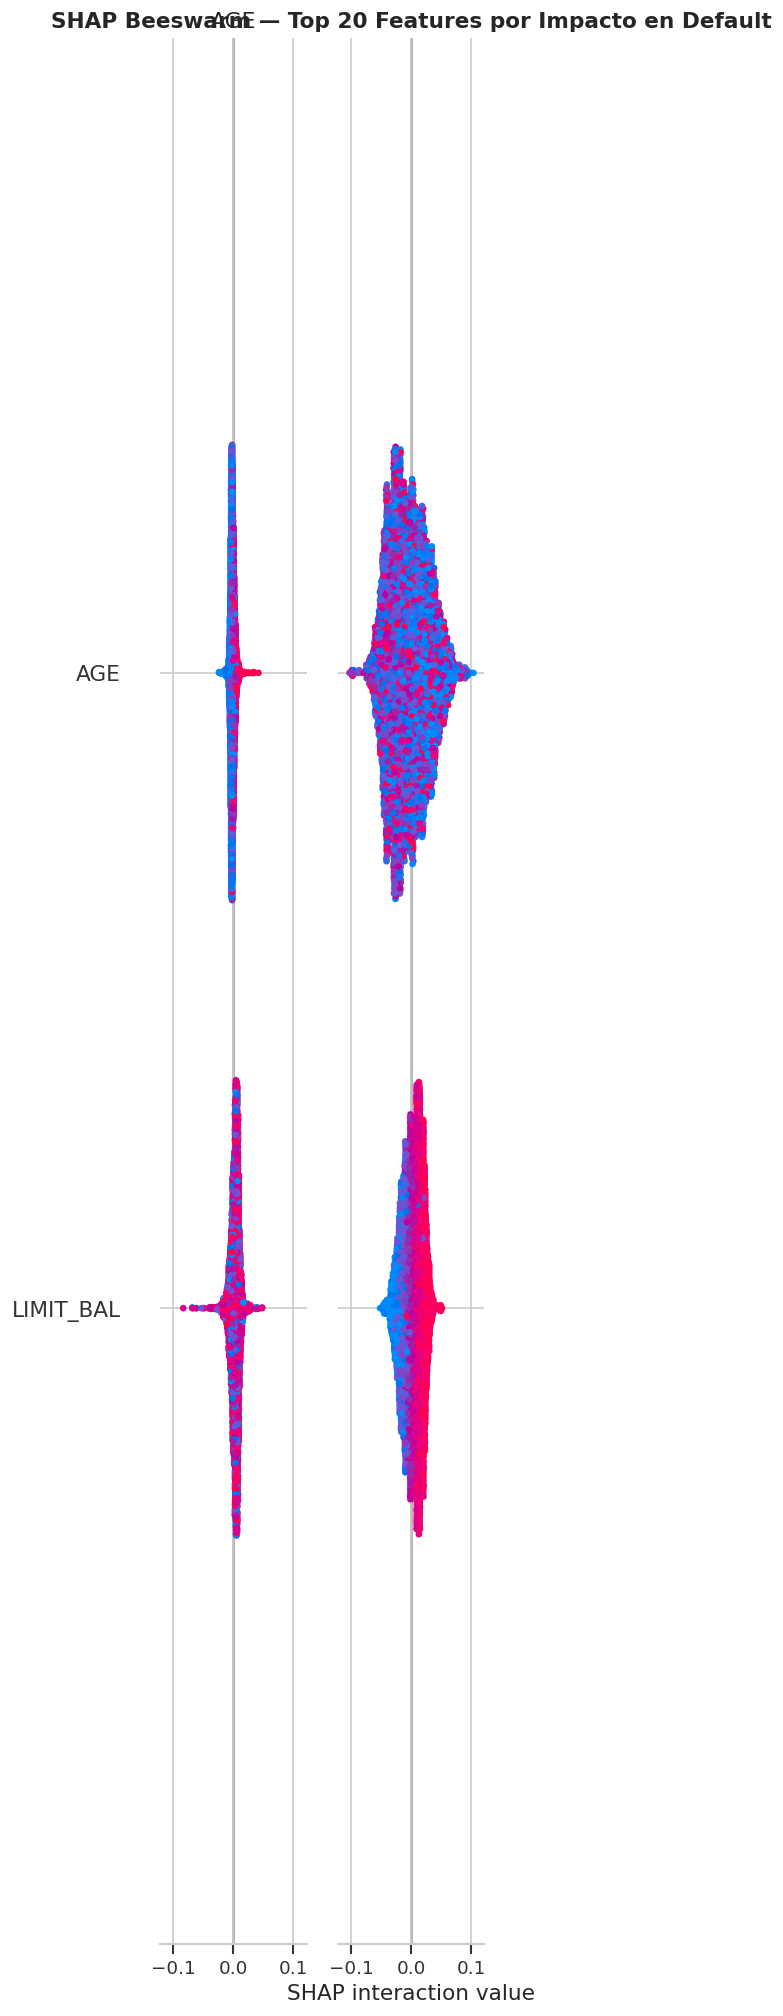

In [21]:
# Beeswarm plot — el más informativo: muestra distribución e impacto de cada feature
plt.figure(figsize=(12, 9))
shap.summary_plot(sv, X_test, plot_type='dot', max_display=20, show=False)
plt.title('SHAP Beeswarm — Top 20 Features por Impacto en Default',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

<Figure size 1200x840 with 0 Axes>

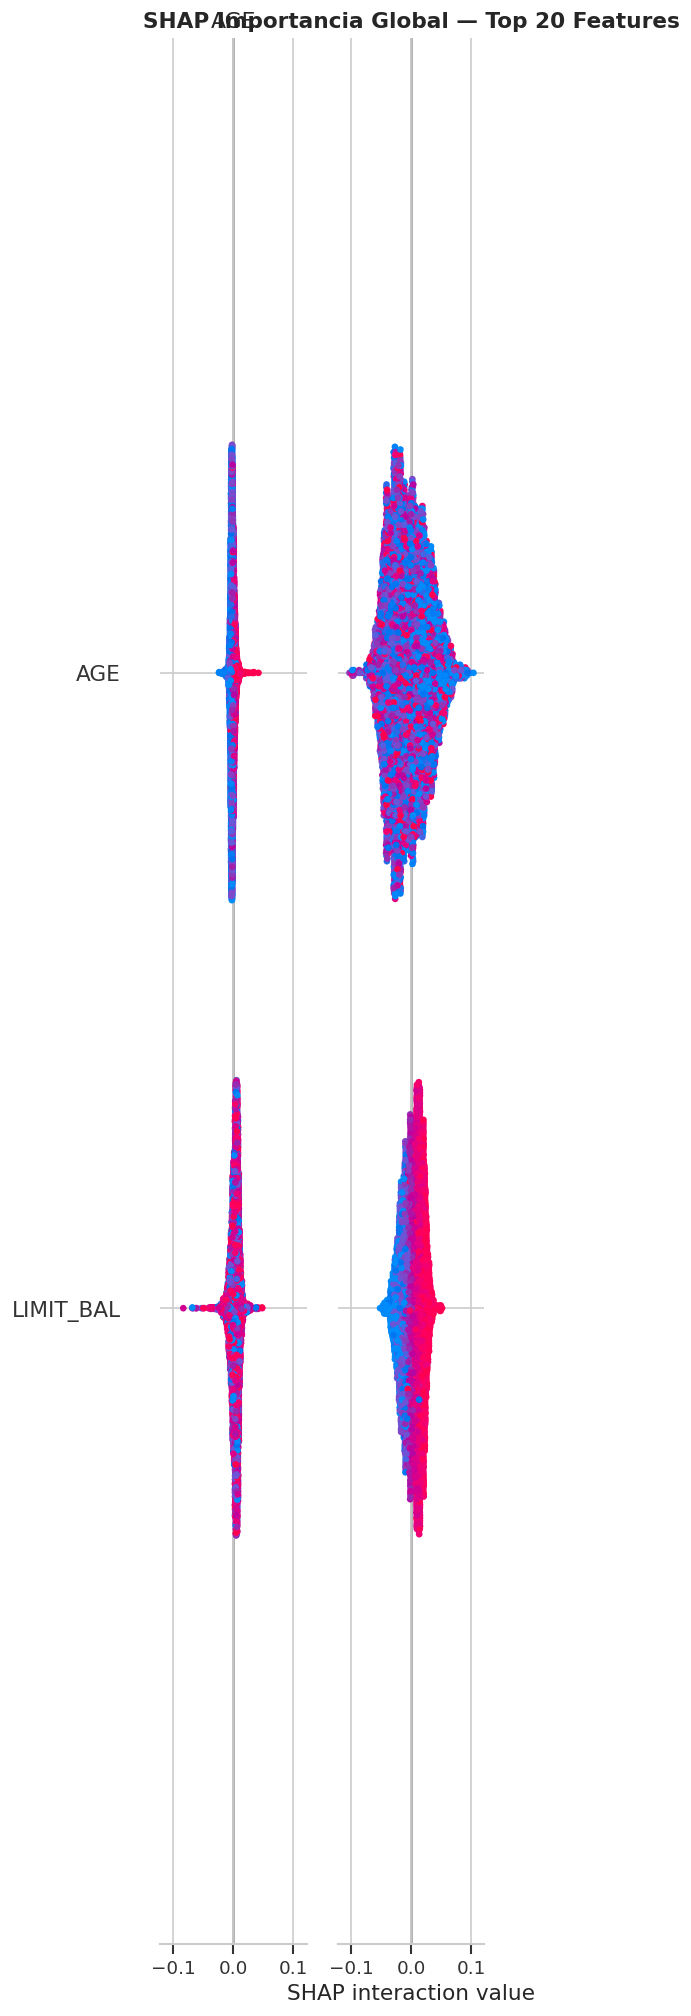

In [22]:
# Bar plot — importancia global promedio
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test, plot_type='bar', max_display=20, show=False)
plt.title('SHAP Importancia Global — Top 20 Features',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

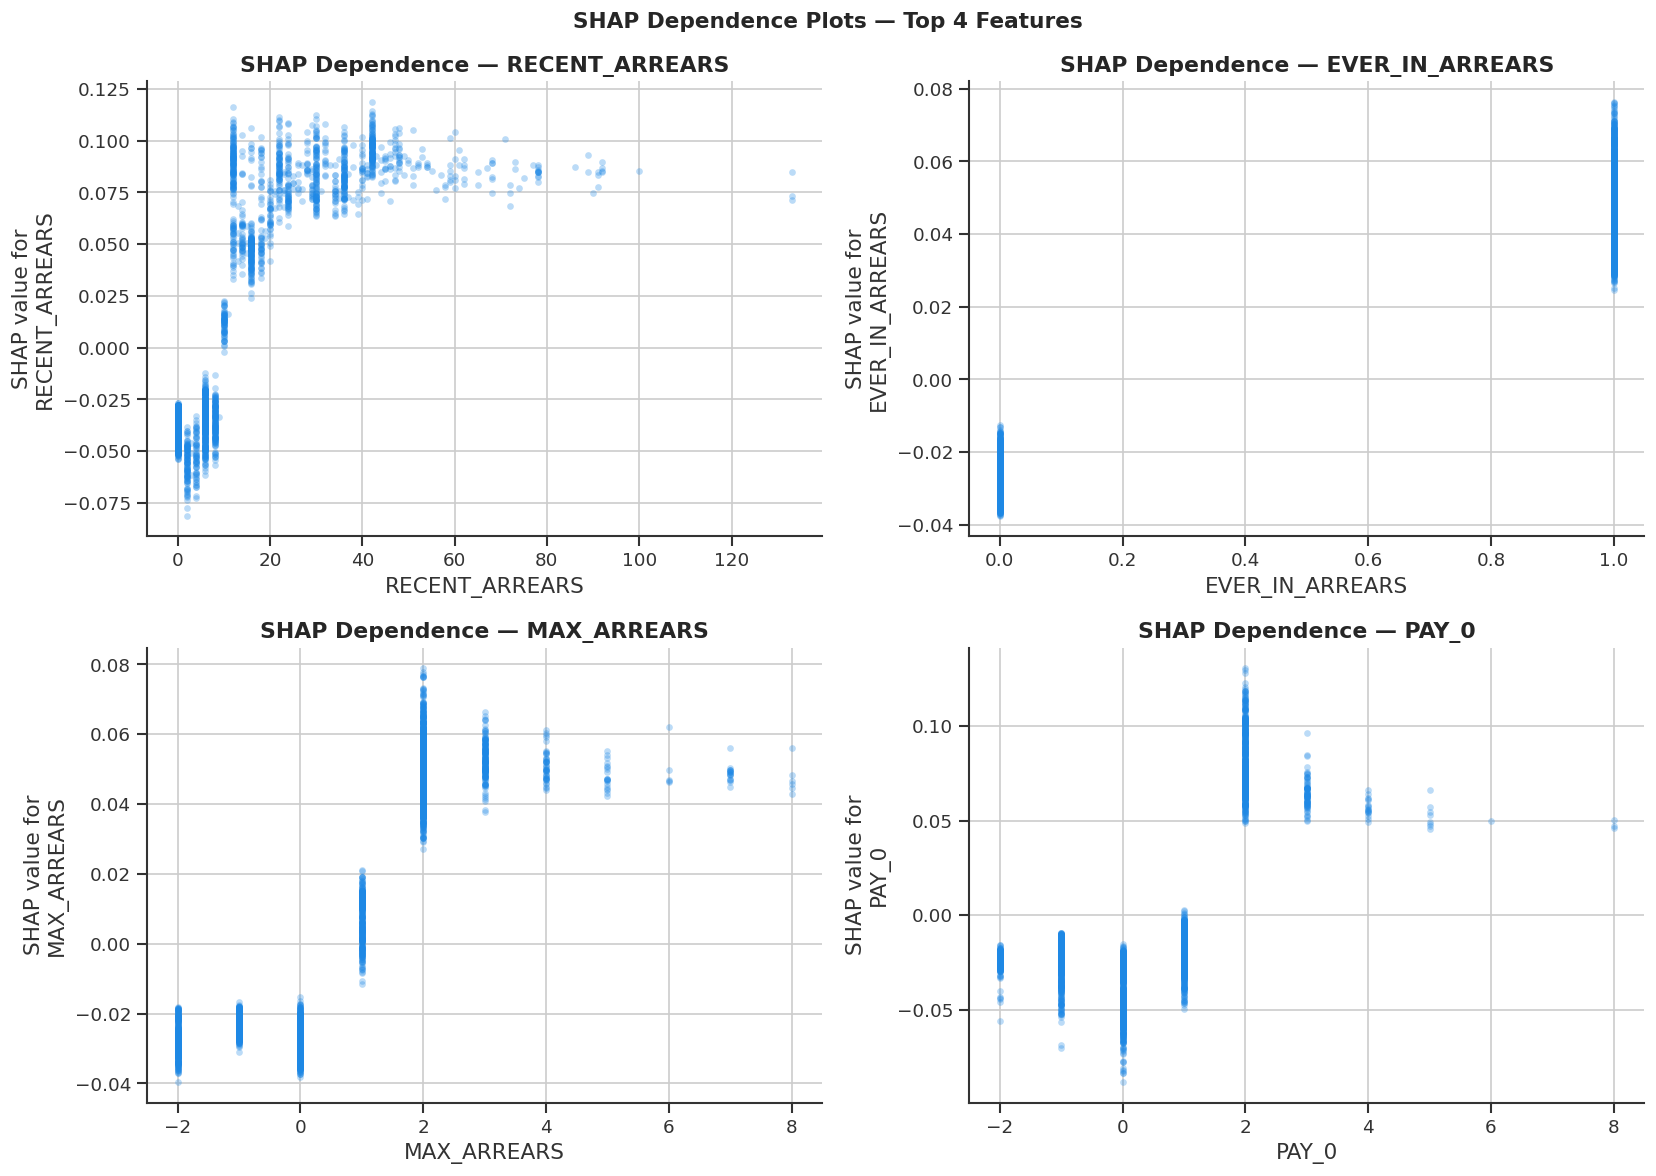

In [31]:
# Dependence plots — las 4 variables más importantes
col_list = X_test.columns.tolist()

# sv tiene shape (6000, 36, 2) — seleccionar clase 1 (default)
sv_class1 = sv[:, :, 1]  # shape (6000, 36)

mean_abs_shap = np.abs(sv_class1).mean(axis=0)  # shape (36,)
top4_idx  = [int(i) for i in np.argsort(mean_abs_shap)[-4:][::-1]]
top4_feat = [col_list[i] for i in top4_idx]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, feat in zip(axes, top4_feat):
    feat_idx = col_list.index(feat)
    shap.dependence_plot(
        feat_idx, sv_class1, X_test.values,
        feature_names=col_list,
        interaction_index=None,
        ax=ax, show=False, alpha=0.3
    )
    ax.set_title(f'SHAP Dependence — {feat}', fontweight='bold')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Cliente con mayor probabilidad de default en el test set:
  Índice en test set:          5461
  Probabilidad de default:     0.9611
  Target real:                 1 (Default)


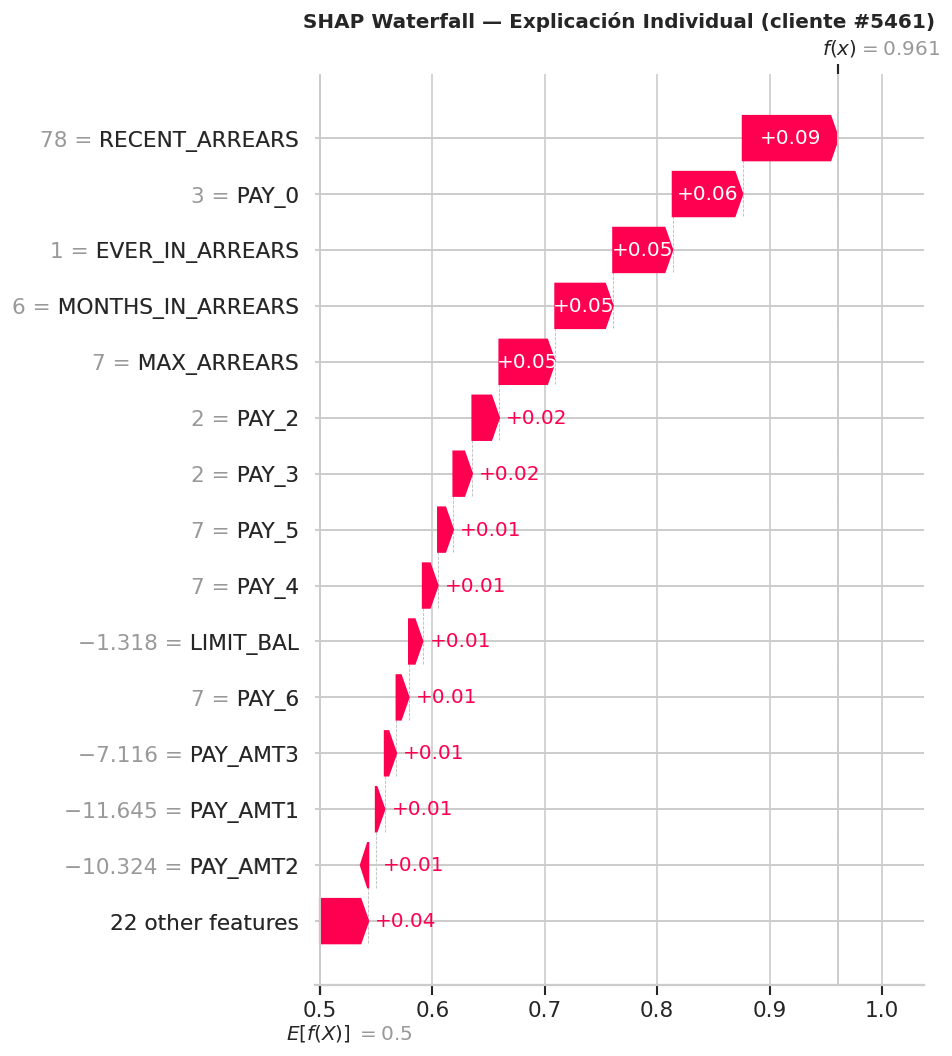

In [33]:
# Waterfall plot — explicación de una predicción individual
idx_max_risk = prob_best.argmax()

print(f'Cliente con mayor probabilidad de default en el test set:')
print(f'  Índice en test set:          {idx_max_risk}')
print(f'  Probabilidad de default:     {prob_best[idx_max_risk]:.4f}')
print(f'  Target real:                 {y_test.values[idx_max_risk]} ({"Default" if y_test.values[idx_max_risk]==1 else "Sin Default"})')

# Seleccionar clase 1 para el cliente específico — shape (36,)
sv_individual = sv[idx_max_risk, :, 1]

# Base value para clase 1
base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

explanation = shap.Explanation(
    values       = sv_individual,
    base_values  = float(base_val),
    data         = X_test.iloc[idx_max_risk].values,
    feature_names= X_test.columns.tolist()
)

plt.figure(figsize=(12, 7))
shap.waterfall_plot(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Explicación Individual (cliente #{idx_max_risk})',
          fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

---
## 13. Exportación del Modelo

Se exportan todos los artefactos necesarios para reproducir las predicciones del modelo sin necesidad de reentrenar.

In [34]:
os.makedirs('../models', exist_ok=True)

# Modelo entrenado
joblib.dump(best_model, '../models/model.pkl')

# Metadatos del modelo para trazabilidad
model_metadata = {
    'modelo':            winner,
    'umbral':            float(OPTIMAL_THRESHOLD),
    'hiperparametros':   {k: str(v) for k, v in search.best_params_.items()},
    'metricas_test': {
        'roc_auc':   round(roc_auc_score(y_test, prob_best), 4),
        'pr_auc':    round(average_precision_score(y_test, prob_best), 4),
        'recall':    round(recall_score(y_test, y_pred_final), 4),
        'precision': round(precision_score(y_test, y_pred_final), 4),
        'f1':        round(f1_score(y_test, y_pred_final), 4),
        'brier':     round(brier_score_loss(y_test, prob_best), 4)
    },
    'n_features':        int(X_test.shape[1]),
    'feature_names':     X_test.columns.tolist(),
    'seed':              SEED
}

with open('../models/model.txt', 'w') as f:
    json.dump(model_metadata, f, indent=2)

print('Artefactos exportados:')
for fname in os.listdir('../models/'):
    size = os.path.getsize(f'../models/{fname}')
    print(f'  ../models/{fname}  ({size/1024:.1f} KB)')

print('\n✅ Modelo listo para uso en producción.')
print(f'   Para predecir: modelo.predict_proba(X)[:, 1] >= {OPTIMAL_THRESHOLD:.2f}')

Artefactos exportados:
  ../models/model.pkl  (11558.8 KB)
  ../models/model.txt  (1.0 KB)

✅ Modelo listo para uso en producción.
   Para predecir: modelo.predict_proba(X)[:, 1] >= 0.42


---
### Resumen del Proceso de Modelado

| Etapa | Decisión | Justificación |
|-------|----------|---------------|
| Baseline | Regresión Logística con `class_weight='balanced'` | Punto de referencia interpretable y auditable |
| Candidatos | RF, XGBoost, LightGBM | Modelos de ensamble con alto poder predictivo en tabular data |
| Selección | Mayor CV ROC-AUC + Val Recall competitivo | Métricas prioritarias del Business Understanding |
| Optimización | RandomizedSearchCV (40 iteraciones, 5-fold CV) | Balance entre exhaustividad y costo computacional |
| Umbral | Máximo F1 con Recall ≥ 0.65 | Prioridad al recall; asimetría de costos FN > FP |
| Interpretabilidad | SHAP TreeExplainer | Explicabilidad individual y global para auditoría |

---
*Fin del Modelado — continuar con `06_conclusions.ipynb`*